In [106]:

import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import re

In [145]:
data_dir = Path("../data")

# All 7 CSV files that share the 16-column schema
csv_files = [
    data_dir / "Core-Processors-1.8.csv",
    data_dir / "Xeon-Processors-1.8.csv",
    data_dir / "Atom-Processors-1.9-16col.csv",
    data_dir / "Celeron-Processors-1.9-16col.csv",
    data_dir / "Core_Ultra-Processors-1.10-16col.csv",
    data_dir / "Intel-Processors-1.9-16col.csv",
    data_dir / "Pentium-Processors-1.9-16col.csv",
]



In [146]:
def classify_suffix(name):
    # Extract trailing letters after the last number
    m = re.search(r'(\d+)([A-Z]+[0-9]?)$', name)
    suffix = m.group(2) if m else ""
    
    # Group into power tiers
    if suffix in ("K", "KF", "KS", "X", "XE", "HK", "HX"):
        return "High Perf"
    elif suffix in ("H", "HQ", "HL", "HE", "QM", "MQ"):
        return "High Perf Mobile"
    elif suffix in ("U", "UM", "UL", "UE"):
        return "Ultra-Low Power"
    elif suffix == "Y":
        return "Extreme Low Power"
    elif suffix in ("T", "TE"):
        return "Power Optimized"
    elif suffix in ("N", "NT", "NTE"):
        return "Low Power"
    elif suffix in ("E", "EQ", "EC"):
        return "Embedded"
    elif suffix in ("F", "KF"):
        return "No Graphics"
    elif suffix in ("M",):
        return "Mobile (Legacy)"
    elif suffix in ("S", "P", "G", "G1", "G4", "G7"):
        return "Standard / Graphics"
    elif suffix in ("B", "R", "RE", "RK"):
        return "BGA / Soldered"
    else:
        return "Standard"  # includes no suffix






In [147]:
# Read each file and collect the DataFrames
frames = []
for f in csv_files:
    print(f"Loading {f.name} ...")
    df = pd.read_csv(f)
    family = f.stem.split("-")[0]
    # "Core-Processors-1.8" → "Core"
    # "Core-Ultra-Processors-1.10" → "Core-Ultra"
    df["Vertical Segment"] = family
    frames.append(df)



family_map = {
    "Atom": "Atom", "Celeron": "Celeron", "Core": "Core",
    "CoreUltra": "Core Ultra", "Intel": "Intel",
    "Pentium": "Pentium", "Xeon": "Xeon"
}


df = pd.concat(frames, ignore_index=True)
df["Release Date"] = df["Release Date"].str[-2:].astype(int) + 2000
df["Power Tier"] = df["Product"].apply(classify_suffix)
print(df["Power Tier"].value_counts())


print(df.dtypes)


Loading Core-Processors-1.8.csv ...
Loading Xeon-Processors-1.8.csv ...
Loading Atom-Processors-1.9-16col.csv ...
Loading Celeron-Processors-1.9-16col.csv ...
Loading Core_Ultra-Processors-1.10-16col.csv ...
Loading Intel-Processors-1.9-16col.csv ...
Loading Pentium-Processors-1.9-16col.csv ...
Power Tier
Standard               1418
Ultra-Low Power         222
Power Optimized         190
High Perf Mobile        178
High Perf               122
Standard / Graphics     102
Mobile (Legacy)          88
Embedded                 81
Low Power                65
Extreme Low Power        56
BGA / Soldered           50
No Graphics              35
Name: count, dtype: int64
Product                      str
Status                       str
Release Date               int64
Code Name                    str
Cores                      int64
Threads                  float64
Lithography(nm)          float64
Max. Turbo Freq.(GHz)    float64
Base Freq.(GHz)          float64
TDP(W)                   float64
C

In [126]:
df.sample()

,Product,Status,Release Date,Code Name,Cores,Threads,Lithography(nm),Max. Turbo Freq.(GHz),Base Freq.(GHz),TDP(W),Cache(MB),Cache Info,Max Memory Size(GB),Memory Types,Max Memory Speed(MHz),Integrated Graphics,Vertical Segment,Suffix
934,Core i5-460M,Discontinued,2010,Arrandale,2,4.0,32.0,2.8,2.53,35.0,3.0,Intel Smart Cache,8.0,DDR3 800/1066,NaN,Intel HD Graphics for Previous Gen Intel Proce...,Core,M


In [134]:


featuresToClean  = ["Lithography(nm)", "Cores", "TDP(W)", "Release Date", "Max. Turbo Freq.(GHz)"]

# Only convert the columns we actually need 
cols_to_clean = featuresToClean
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=cols_to_clean, inplace=True)
print(f"Samples after cleaning: {len(df)}")

Samples after cleaning: 1855


In [ ]:
family_dummies = pd.get_dummies(df["Vertical Segment"], prefix="fam", drop_first=True)
tier_dummies = pd.get_dummies(df["Power Tier"], prefix="tier", drop_first=True)


X = pd.concat([
    df[["Lithography(nm)", "Cores", "TDP(W)", "Release Date"]],
    family_dummies
], axis=1)

y = df["Max. Turbo Freq.(GHz)"]


print(f"Clean samples: {len(df)}")


Clean samples: 1855


In [139]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



In [140]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [141]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)


In [142]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


print("Training set:")
print(f"  R²   = {r2_score(y_train, y_pred_train):.4f}")
print(f"  MAE  = {mean_absolute_error(y_train, y_pred_train):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_train, y_pred_train):.4f} GHz")

print("\nTest set:")
print(f"  R²   = {r2_score(y_test, y_pred_test):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_test):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_test, y_pred_test):.4f} GHz")



Training set:
  R²   = 0.6327
  MAE  = 0.3955 GHz
  RMSE = 0.5113 GHz

Test set:
  R²   = 0.6225
  MAE  = 0.3859 GHz
  RMSE = 0.4788 GHz


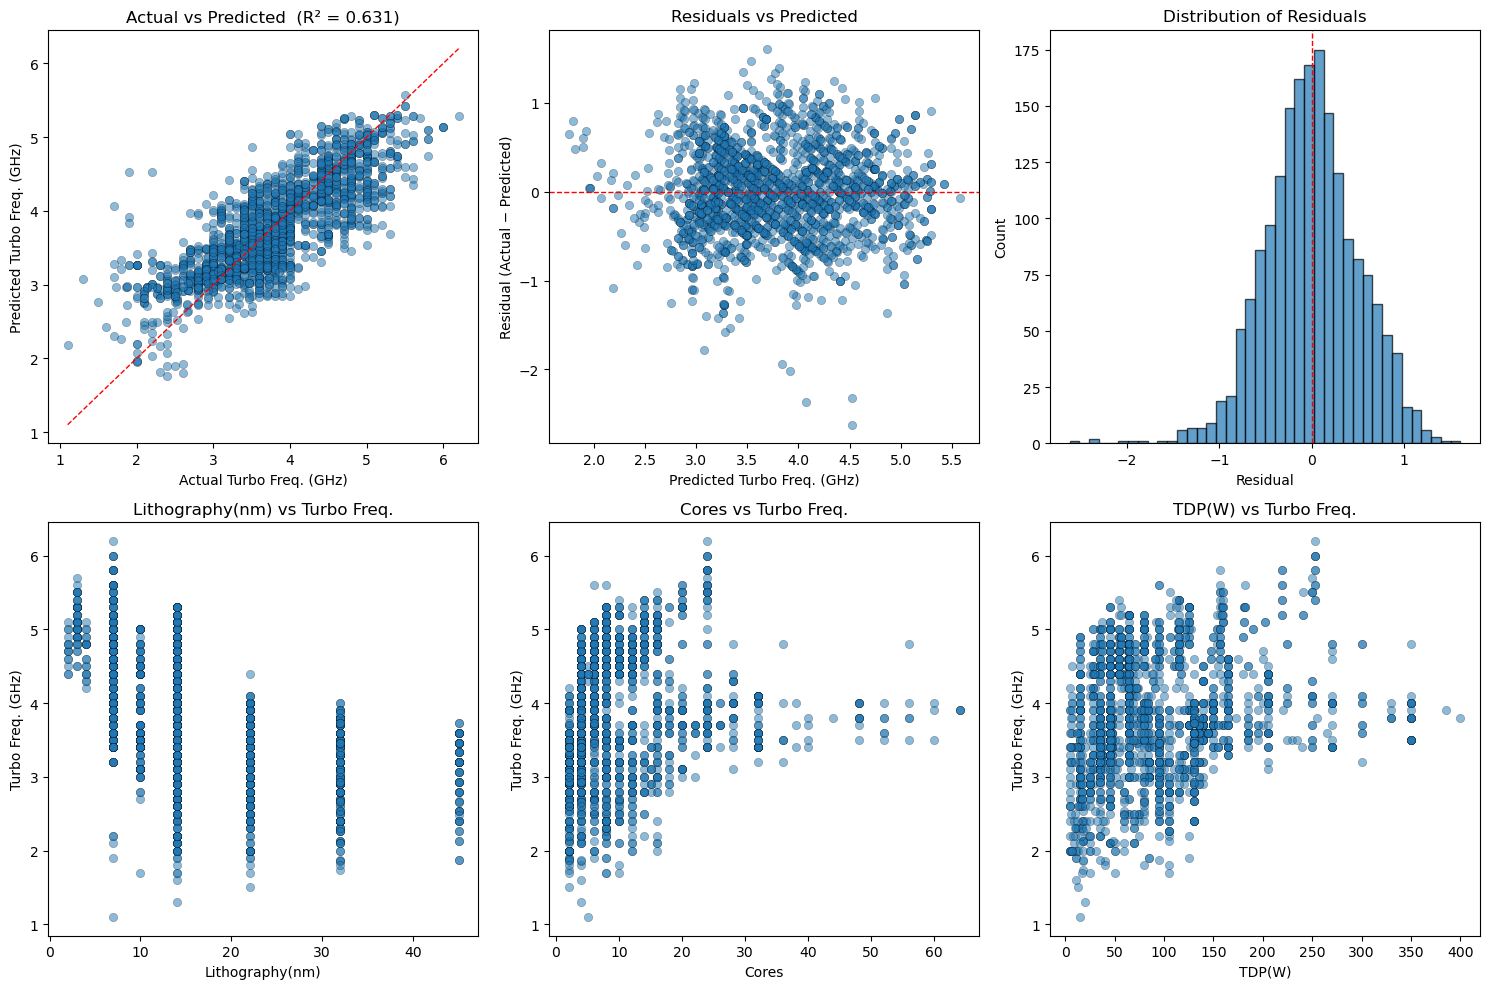

In [143]:
import matplotlib.pyplot as plt

# ── Predict ──────────────────────────────────────────────────
y_pred = model.predict(X_scaled)
residuals = y - y_pred

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1 ── Actual vs Predicted ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y, y_pred, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual Turbo Freq. (GHz)")
ax.set_ylabel("Predicted Turbo Freq. (GHz)")
ax.set_title(f"Actual vs Predicted  (R² = {r2_score(y, y_pred):.3f})")

# 2 ── Residuals vs Predicted ─────────────────────────────────
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.axhline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted Turbo Freq. (GHz)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs Predicted")

# 3 ── Histogram of Residuals ─────────────────────────────────
ax = axes[0, 2]
ax.hist(residuals, bins=40, edgecolor="k", alpha=0.7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Distribution of Residuals")

# 4, 5, 6 ── Feature vs Target ────────────────────────────────
features = ["Lithography(nm)", "Cores", "TDP(W)"]
for i, (feat, ax) in enumerate(zip(features, [axes[1, 0], axes[1, 1], axes[1, 2]])):
    ax.scatter(X[feat], y, alpha=0.5, edgecolors="k", linewidth=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel("Turbo Freq. (GHz)")
    ax.set_title(f"{feat} vs Turbo Freq.")

plt.tight_layout()
plt.show()

In [ ]:
# No